# `lit-pcaslice` — the slicing direction from the data, the centre from each slice

**One of seven methods** in the Phase 4 comparison (`notes/dataset_plan.md` §4). Source:

> Tianqi Wang, Yifan Liang, Xinqi Liu, Zhigang Wang.
> *3D vision-based intersecting pipe welding path planning.*
> **Welding in the World (2026).**

| stage | here |
|---|---|
| YOLO11 boxes each weld **instance**; improved DeepLab V3+ segments the weld pixels; pixel mapping lifts them to a weld cloud | a **per-instance band oracle** — one mask per truth seam |
| Gaussian + statistical filtering (§4.1) | `statistical_filter` |
| PCA principal direction → project → uniform slices → per-slice **geometric centre** (§4.2) | `pca_centerline` |
| cubic NURBS fit (§4.3 — uniform weights, so the same curve family as a cubic B-spline) | `bspline_path` |
| torch posture: MSAC + WTLSD planes, dihedral bisector, 5 mm tube radius (§4.4) | `msac_wtlsd_plane`, `torch_poses` |

Published: welding accuracy **within 1 mm** on intersecting-pipe saddle welds. The slice
width, MSAC tolerance and filter constants are unpublished.

**Two structural facts drive everything below.** First, the coarse stage is
per-instance — §4.2 only ever sees ONE strip — and that is not a convenience: a slice's
geometric centre with two seams inside is the midpoint of neither. Second, the *path*
pipeline is deterministic; MSAC's sampling feeds only the torch posture, which Phase 4
does not score — so the registry carries `randomised=False` with the seed threaded for
the day pose metrics land.

The plan's note stands: this method is **most interesting at Phase 6**, where seams curve
and adaptive slicing has something to adapt to. On straight seams it is nearly a ruler.

In [1]:
import sys
sys.path.insert(0, "..")
sys.path.insert(0, "../scripts")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from baselines import balanced_corpus, prepare, run_matrix, spread
from baselines.lit_pcaslice import bspline_path, detect, pca_centerline
from baselines.lit_ransac import seam_region_oracle

CORPUS = balanced_corpus("../out/bench", per_type=50)
print({k: len(v) for k, v in CORPUS.items()})

def view3d(ax, cloud_pts, gt, pred_polys, extras=(), zoom=1.0, centre="cloud",
           elev=24, azim=-60, cloud_step=None):
    """One 3D panel in the house style: grey cloud, green truth, red prediction.

    `extras` is a list of (points, kwargs) scatter layers - planes, feature corridors,
    registered models. `zoom` < 1 closes in on `centre` ("cloud" or "seam").
    """
    import numpy as np
    P = np.asarray(cloud_pts)
    gt_pts = np.vstack(gt) if len(gt) else P
    c0 = gt_pts.mean(0) if centre == "seam" else 0.5 * (P.min(0) + P.max(0))
    half = 0.55 * float((P.max(0) - P.min(0)).max()) * float(zoom)
    step = cloud_step or max(1, len(P) // 6000)
    ax.scatter(*P[::step].T, s=0.4, c="#dcdcdc", depthshade=False)
    for pts_, kw in extras:
        if len(pts_):
            ax.scatter(*np.asarray(pts_).T, **{"s": 4, "alpha": 0.6,
                                               "depthshade": False, **kw})
    for k, g in enumerate(gt):
        ax.plot(*np.asarray(g).T, lw=6, c="#1a7f37", alpha=0.5, zorder=8,
                solid_capstyle="round", label="ground truth" if k == 0 else None)
    for k, s_ in enumerate(pred_polys):
        ax.plot(*np.asarray(s_).T, lw=2.5, c="#d1242f", zorder=12,
                label="prediction" if k == 0 else None)
    for i, setter in enumerate((ax.set_xlim, ax.set_ylim, ax.set_zlim)):
        setter(c0[i] - half, c0[i] + half)
    ax.set_box_aspect([1, 1, 1])
    ax.view_init(elev=elev, azim=azim)
    ax.legend(fontsize=6.5, loc="upper left")

{'T': 50, 'butt': 50, 'corner': 50, 'edge': 50, 'lap': 50}


## The mechanism on synthetic strips — including the one it cannot survive

Left: a curved strip, the case the paper is built for — the slice centres track the bend
with no axis chosen by hand. Right: **two** parallel strips in one instance mask. Every
slice centre is the geometric centre of both, i.e. the midpoint of neither — the same
mid-surface failure that made `ours` delete its line fit, arrived at through a different
mechanism.

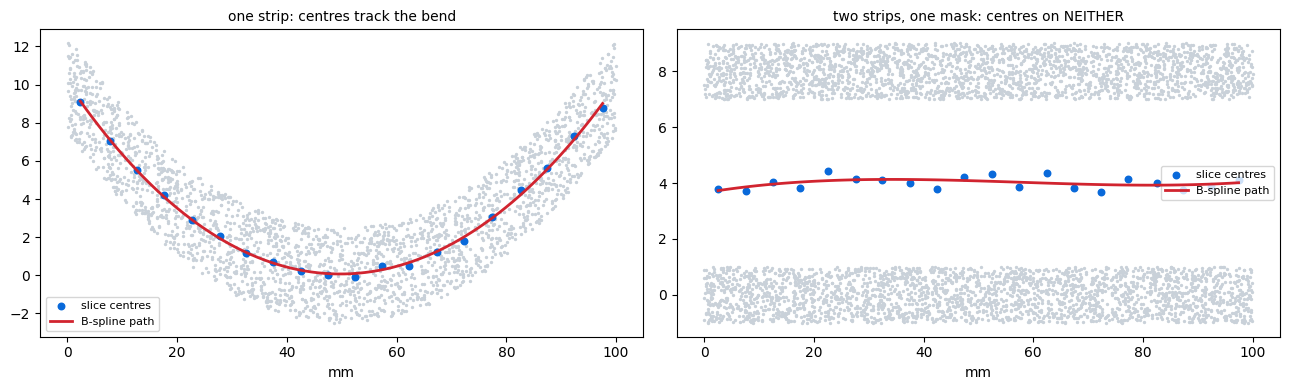

In [2]:
rng = np.random.default_rng(0)
def strip(seed=0, curve=0.0, width=5.0, y0=0.0):
    r = np.random.default_rng(seed)
    t = r.uniform(0, 100, 2500)
    return np.column_stack([t, y0 + curve * (t - 50) ** 2 / 100
                            + r.uniform(-width / 2, width / 2, 2500),
                            r.normal(0, 0.2, 2500)])

curved = strip(curve=0.4)
two = np.vstack([strip(0, width=2.0), strip(1, width=2.0, y0=8.0)])

fig, axes = plt.subplots(1, 2, figsize=(13, 4.0))
for ax, pts, ttl in ((axes[0], curved, "one strip: centres track the bend"),
                     (axes[1], two, "two strips, one mask: centres on NEITHER")):
    ax.scatter(pts[:, 0], pts[:, 1], s=2, c="#c9d1d9")
    cs = pca_centerline(pts, slice_mm=5.0)
    path = bspline_path(cs, 80)
    ax.scatter(cs[:, 0], cs[:, 1], s=22, c="#0969da", zorder=5, label="slice centres")
    ax.plot(path[:, 0], path[:, 1], c="#d1242f", lw=2, zorder=6, label="B-spline path")
    ax.set_title(ttl, fontsize=10); ax.legend(fontsize=8); ax.set_xlabel("mm")
plt.tight_layout(); plt.show()

## One scene, in 3D

A T joint: two fillets, so two YOLO instances. Blue points are the slice centres inside
each per-instance band; the red curves are the fitted paths against the exact truth.

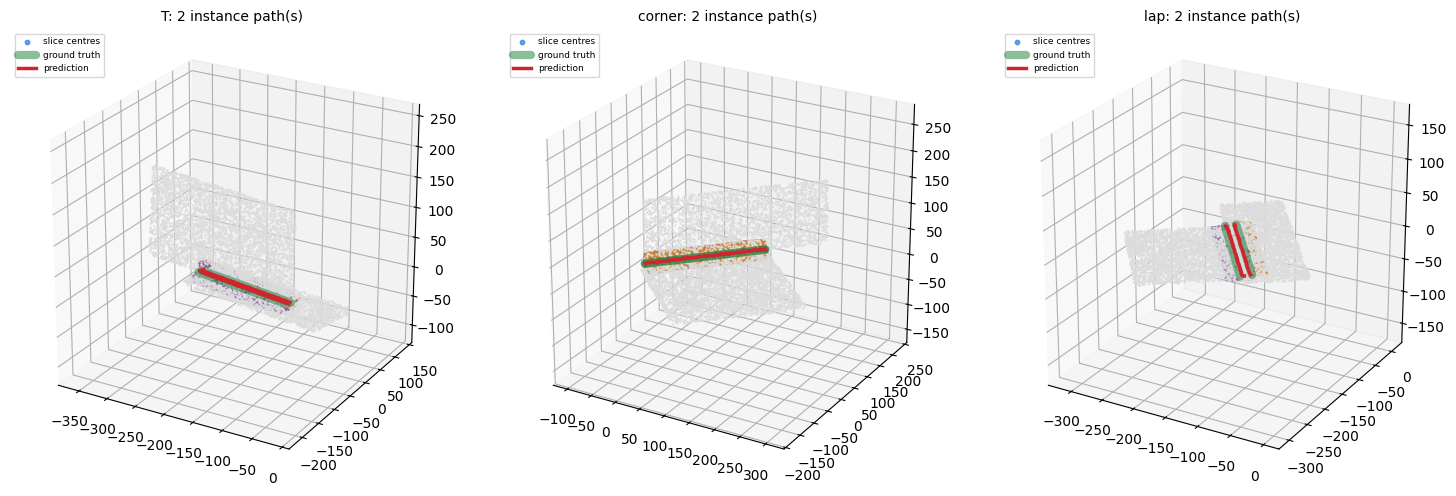

In [3]:
prep = prepare(CORPUS["T"][:1] + CORPUS["corner"][:1] + CORPUS["lap"][:1])
ELEV, AZIM = 24, -60

fig = plt.figure(figsize=(15, 4.8))
for k, p_ in enumerate(prep):
    c = p_.cloud("full", 0.0)
    masks = [seam_region_oracle(c["xyz"], [g], end_margin_mm=0.0) for g in p_.gt]
    r = detect(c["xyz"], instance_masks=masks)
    ax = fig.add_subplot(1, 3, k + 1, projection="3d")
    extras = [(np.vstack(r.centers) if r.centers else np.zeros((0, 3)),
               {"c": "#0969da", "s": 10, "label": "slice centres"})]
    for gi, m in enumerate(masks):
        extras.append((c["xyz"][m][::12], {"c": ["#d1842f", "#8f5fa8"][gi % 2],
                                           "s": 1.5, "alpha": 0.25}))
    view3d(ax, c["xyz"], p_.gt, r.polylines, extras, elev=ELEV, azim=AZIM)
    ax.set_title(f"{p_.facts['joint_type']}: {r.n_seams} instance path(s)", fontsize=10)
plt.tight_layout(); plt.show()

## The corpus, through the harness

`L0` = one band per truth seam (their per-instance YOLO stage). `L1` = the whole cloud as
a single instance — the broken-assumption arm, and on multi-seam scenes it must fail at
the mechanism, not at a threshold.

In [4]:
prep_all = prepare([d for jt in ("T", "corner", "butt", "lap", "edge")
                    for d in CORPUS[jt][:12]])
frames = []
for arm in (True, False):
    d = run_matrix(prep_all, methods=["lit-pcaslice"], seeds=range(1), verify_seeds=1,
                   oracle=arm)
    frames.append(d)
corp = pd.concat(frames, ignore_index=True)
corp.groupby(["arm", "joint_type"]).agg(
    prec=("precision", "mean"), rec=("recall", "mean"), f1=("f1", "mean"),
    rmse=("rmse_med", "median"), me=("me_med", "median"),
    seam_rec=("seam_recall", "mean")).round(3)

prec    rec     f1     rmse       me  seam_rec
arm joint_type                                                 
L0  T           0.924  0.937  0.931    2.000    4.624     1.000
    butt        0.400  0.364  0.378    4.417    5.688     1.000
    corner      0.651  0.565  0.596    2.739    3.950     1.000
    edge        0.000  0.000  0.000    9.489   10.039     1.000
    lap         0.497  0.547  0.520    3.057    4.852     1.000
L1  T           0.037  0.065  0.046   77.208  177.864     0.542
    butt        0.004  0.008  0.005  106.689  213.208     0.542
    corner      0.000  0.000  0.000  103.039  183.672     0.528
    edge        0.000  0.000  0.000   93.091  161.319     0.958
    lap         0.029  0.047  0.035   76.611  162.595     0.500

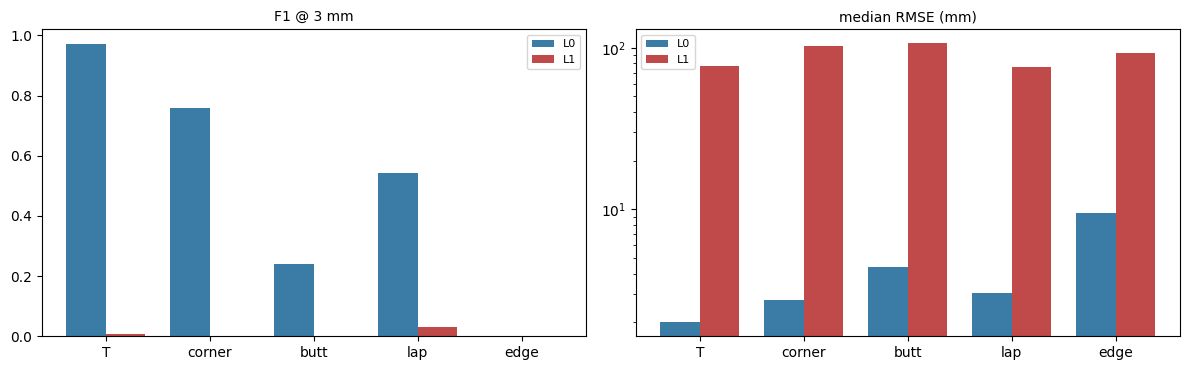

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
order = ["T", "corner", "butt", "lap", "edge"]
x = np.arange(len(order)); w = 0.38
for ax, metric in zip(axes, ("f1", "rmse_med")):
    for k, arm in enumerate(("L0", "L1")):
        sub = corp[corp.arm == arm]
        vals = [sub[sub.joint_type == j][metric].median() for j in order]
        ax.bar(x + (k - 0.5) * w, vals, w, label=arm, color=["#3a7ca5", "#c04a4a"][k])
    ax.set_xticks(x); ax.set_xticklabels(order); ax.legend(fontsize=8)
    ax.set_title({"f1": "F1 @ 3 mm", "rmse_med": "median RMSE (mm)"}[metric], fontsize=10)
axes[1].set_yscale("log")
plt.tight_layout(); plt.show()

## Open questions

- **Phase 6 is where this method earns its seat.** Straight seams give the PCA axis and
  the slice centres nothing to adapt to; the saddle curves the paper was built for arrive
  with curved seams. Keep the corpus numbers here as the straight-seam baseline to compare
  against when they do.
- **The per-instance oracle is doing more work than any other coarse stage in the seven.**
  It solves seam *separation* — the exact problem `ours`, `lit-regiongrow` and `lit-lobb`
  are all stopped by — in 2D, before the point cloud is ever touched. Worth saying in the
  comparison: their YOLO stage is not localisation, it is instance segmentation of the
  problem itself.
- **Torch posture is computed and unscored**, like every method here; MSAC's seed
  threading waits for pose metrics.